In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from workalendar.asia import SouthKorea 

# statsmodel 확인
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
from torch.utils.data import DataLoader, TensorDataset

# 오류 무시하는 방법
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/mnt/nvme/zongseung/SCI/기후데이터/demand_celcius.csv")
df = df.set_index("일시")
df = df.drop("Unnamed: 0", axis=1)
df.index = pd.to_datetime(df.index)

In [4]:
import datetime as dt
cal = SouthKorea()

def holiday_weekday(data):
    holiday_data = []

    for date in data.index:

        if date.weekday() in [5, 6] or cal.is_holiday(date) is True:  # 주말 (토요일=5, 일요일=6) / 공휴일까지 포함시켜서 확인한다.
            holiday_data.append(2) # 2번은 쉬는날
        else:  # 그 외 날짜 
            holiday_data.append(1) # 안쉬는날

    data["holiday_data"] = holiday_data    
    
    return data

def get_season_by_month(month):
    asd = []
    
    for i in month: 
        if 3 <= i <= 5: 
            asd.append(1) # 봄
        elif 6 <= i <= 8:
            asd.append(2) # 여름
        elif 9 <= i <= 11:
            asd.append(3)
        else:
            asd.append(4)
    return asd

In [5]:
def select_date(data):

        dummies = pd.get_dummies(data["holiday_data"]).astype("int")
        season_dummies = pd.get_dummies(data["season"]).astype("int")
        
        data = pd.concat([data, dummies], axis = 1)
        data.drop(["holiday_data", "season"], axis=1, inplace=True)

        data.rename(columns = {1:"weekday",
        2:"weekend"}, inplace=True)

        data = pd.concat([data, season_dummies], axis = 1)

        data.rename(columns = {1:"spring",
        2:"summer",
        3:"autoum",
        4:"winter"}, inplace=True)
        
        return data

In [6]:
import datetime as dt
df["month"] = df.index.month

df_holiday = holiday_weekday(df)
df_holiday["season"] = get_season_by_month(df_holiday["month"])
df.reset_index(inplace=True)
# 연,월,일 생성
df["ymd"] = df["일시"].dt.strftime('%Y-%m-%d')

# 더미 변수 생성
df = select_date(df)

In [7]:
from lunarcalendar import Converter, Solar, Lunar

def get_solar_date(year, lunar_month, lunar_day):
    """음력 날짜를 양력으로 변환"""
    lunar_date = Lunar(year, lunar_month, lunar_day)
    solar_date = Converter.Lunar2Solar(lunar_date)
    return pd.Timestamp(solar_date.year, solar_date.month, solar_date.day)  # pandas Timestamp 변환

# 2019~2024년의 설날과 추석 날짜 계산 및 연휴 포함
# 2019~2024년의 설날과 추석 날짜 계산 및 연휴 포함
holiday_dict = {}
for year in range(2019, 2025):
    seollal = get_solar_date(year, 1, 1)  # 설날 본날
    chuseok = get_solar_date(year, 8, 15)  # 추석 본날

    # 연휴 포함 (전날, 당일, 다음날)
    if year==2019:
        
        holiday_dict[seollal - pd.Timedelta(days=1)] = "seol"
        holiday_dict[seollal] = "seol"
        holiday_dict[seollal + pd.Timedelta(days=1)] = "seol"

    
    elif year == 2023:
        holiday_dict[chuseok - pd.Timedelta(days=1)] = "Chuseok"
        holiday_dict[chuseok] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=1)] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=2)] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=3)] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=4)] = "Chuseok"
    
    # 일반적으로 표기하는 경우
    else:
        # 설날
        holiday_dict[seollal - pd.Timedelta(days=1)] = "seol"
        holiday_dict[seollal] = "seol"
        holiday_dict[seollal + pd.Timedelta(days=1)] = "seol"
        # 추석
        holiday_dict[chuseok - pd.Timedelta(days=1)] = "Chuseok"
        holiday_dict[chuseok] = "Chuseok"
        holiday_dict[chuseok + pd.Timedelta(days=1)] = "Chuseok"
        
# `holiday_type` 컬럼 추가
df["ymd"] = pd.to_datetime(df["ymd"])
df["holiday_type"] = df["ymd"].map(holiday_dict).fillna("")

In [8]:
df.reset_index(inplace=True)
df1 = df.groupby("일시")[["hm",	"ta", "power demand(MW)", "weekday", "weekend",	"spring", "summer",	"autoum", "winter"]].mean()

# 외생변수의 표준화 실시
from sklearn.preprocessing import MinMaxScaler
mn = MinMaxScaler()

In [9]:
df.set_index("일시", inplace=True)

df.index = pd.to_datetime(df.index)
df.index = df.index.to_period("H").to_timestamp()

Train: (23503, 13)
Val: (5036, 13)
Test: (5037, 13)


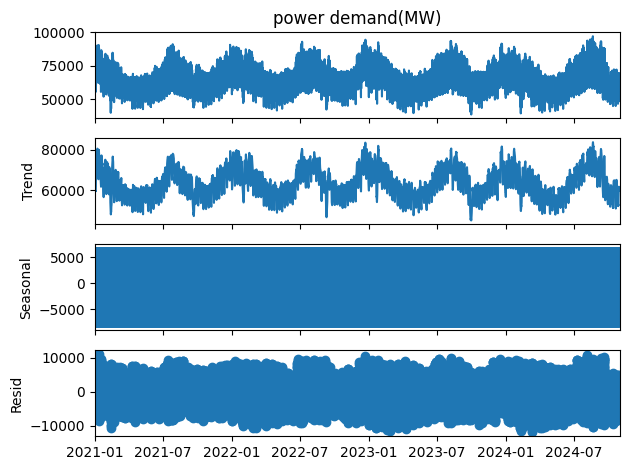

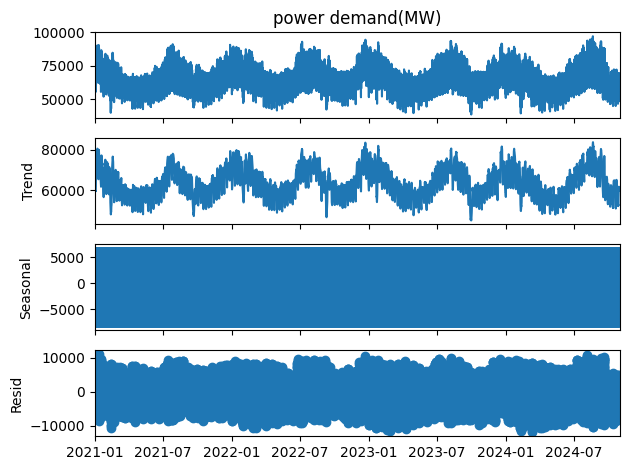

In [10]:
df2 = df[df.index>="2021-01-01"]
df2.drop(["index", "month",  "ymd", "holiday_type"], axis=1, inplace=True)

from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df2['power demand(MW)'], model='additive', period=24)

# 2. 성분 추가
df2['trend'] = decomp.trend
df2['seasonal'] = decomp.seasonal
df2['residual'] = decomp.resid
df2['linear_part'] = df2['trend'] + df2['seasonal']  # SARIMA 예측 대상

# 3. NaN 제거 (앞뒤 trend/seasonal/residual에서 발생한 NaN 제거)
df2 = df2.dropna(subset=['linear_part', 'residual']).reset_index(drop=True)

# 4. 분할 인덱스
total_len = len(df2)
train_end = int(total_len * 0.70)
val_end = int(total_len * 0.85)

# 5. 데이터프레임 분할
train_df = df2.iloc[:train_end].copy()
val_df = df2.iloc[train_end:val_end].copy()
test_df = df2.iloc[val_end:].copy()

# 6. 확인
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)
decomp.plot()

In [19]:
train_df

,hm,ta,power demand(MW),weekday,weekend,spring,summer,autoum,winter,trend,seasonal,residual,linear_part
0,63.541358,-1.341464,56191.0,0,1,0,0,0,1,60252.916667,-970.129835,-3091.786832,59282.786832
1,62.931129,-0.364409,56424.0,0,1,0,0,0,1,60080.541667,1164.581045,-4821.122712,61245.122712
2,62.162698,0.442892,56691.0,0,1,0,0,0,1,59922.500000,2439.323540,-5670.823540,62361.823540
3,63.486420,0.657566,58299.0,0,1,0,0,0,1,59780.375000,3685.816079,-5167.191079,63466.191079
4,66.127954,0.254118,60425.0,0,1,0,0,0,1,59652.645833,5571.329883,-4798.975717,65223.975717
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23498,41.282857,30.070095,75923.0,1,0,0,0,1,0,70116.937500,2439.323540,3366.738960,72556.261040
23499,39.566667,30.470476,77950.0,1,0,0,0,1,0,70071.166667,3685.816079,4193.017254,73756.982746
23500,39.827619,30.421048,80869.0,1,0,0,0,1,0,70028.895833,5571.329883,5268.774283,75600.225717
23501,40.641905,30.005810,81665.0,1,0,0,0,1,0,69991.500000,6319.386650,5354.113350,76310.886650


In [33]:
pd.DataFrame(train_y)

,power demand(MW)
0,56191.0
1,56424.0
2,56691.0
3,58299.0
4,60425.0
...,...
23498,75923.0
23499,77950.0
23500,80869.0
23501,81665.0


In [93]:
train_x = train_df.drop(["power demand(MW)", "trend", "seasonal", "residual", "linear_part"], axis=1)
train_y = train_df["power demand(MW)"]

test_x = test_df.drop(["power demand(MW)", "trend", "seasonal", "residual", "linear_part"], axis=1)
test_y = test_df["power demand(MW)"]

# 정규화
from sklearn.preprocessing import MinMaxScaler
mnx = MinMaxScaler()
mny = MinMaxScaler()

scaled_train_x = mnx.fit_transform(train_x)
scaled_train_y = mny.fit_transform(train_y.values.reshape(-1,1))
scaled_test_x = mnx.transform(test_x)
scaled_test_y = mny.transform(test_y.values.reshape(-1,1))

In [82]:
scaled_train_x

array([[0.58434573, 0.30759597, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.57699251, 0.32684661, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.56773299, 0.34275265, 0.        , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.29859704, 0.9334039 , 1.        , ..., 0.        , 1.        ,
        0.        ],
       [0.30840912, 0.92522258, 1.        , ..., 0.        , 1.        ,
        0.        ],
       [0.37257208, 0.90205218, 1.        , ..., 0.        , 1.        ,
        0.        ]])

In [94]:
train_df

,hm,ta,power demand(MW),weekday,weekend,spring,summer,autoum,winter,trend,seasonal,residual,linear_part
0,63.541358,-1.341464,56191.0,0,1,0,0,0,1,60252.916667,-970.129835,-3091.786832,59282.786832
1,62.931129,-0.364409,56424.0,0,1,0,0,0,1,60080.541667,1164.581045,-4821.122712,61245.122712
2,62.162698,0.442892,56691.0,0,1,0,0,0,1,59922.500000,2439.323540,-5670.823540,62361.823540
3,63.486420,0.657566,58299.0,0,1,0,0,0,1,59780.375000,3685.816079,-5167.191079,63466.191079
4,66.127954,0.254118,60425.0,0,1,0,0,0,1,59652.645833,5571.329883,-4798.975717,65223.975717
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23498,41.282857,30.070095,75923.0,1,0,0,0,1,0,70116.937500,2439.323540,3366.738960,72556.261040
23499,39.566667,30.470476,77950.0,1,0,0,0,1,0,70071.166667,3685.816079,4193.017254,73756.982746
23500,39.827619,30.421048,80869.0,1,0,0,0,1,0,70028.895833,5571.329883,5268.774283,75600.225717
23501,40.641905,30.005810,81665.0,1,0,0,0,1,0,69991.500000,6319.386650,5354.113350,76310.886650


In [96]:
train_x = train_df.drop(["power demand(MW)", "trend", "seasonal", "residual", "linear_part", "spring", "summer", "autoum", "winter"], axis=1)
train_y = train_df["power demand(MW)"]

test_x = test_df.drop(["power demand(MW)", "trend", "seasonal", "residual", "linear_part", "spring", "summer", "autoum", "winter"], axis=1)
test_y = test_df["power demand(MW)"]

# 정규화
from sklearn.preprocessing import MinMaxScaler
mnx = MinMaxScaler()
mny = MinMaxScaler()

scaled_train_x = mnx.fit_transform(train_x)
scaled_train_y = mny.fit_transform(train_y.values.reshape(-1,1))
scaled_test_x = mnx.transform(test_x)
scaled_test_y = mny.transform(test_y.values.reshape(-1,1))

In [125]:
import time
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 1. 로그 변환
log_train_y = np.log(train_df["power demand(MW)"])
log_test_y = np.log(test_df["power demand(MW)"])
log_full_y = pd.concat([log_train_y, log_test_y], ignore_index=True)

# 2. 파라미터 설정
window_size = 168  # 7일
n_periods = 24     # 하루 예측
start_index = 0
predictions = []
start_time = time.time()

# 3. 롤링 SARIMA 예측
for i in range(start_index, len(log_test_y), n_periods):
    try:
        step = min(n_periods, len(log_test_y) - i)
        
        window_start = len(log_train_y) + i - window_size
        window_end = len(log_train_y) + i

        if window_start < 0:
            print(f"⚠️ Step {i}: 학습 데이터 부족 (윈도우 범위 오류) → skip")
            continue

        # 4. 학습 데이터 슬라이싱
        train_endog = log_full_y.iloc[window_start:window_end].astype(float)

        # 5. 모델 재학습
        print(f"🔄 SARIMA 모델 업데이트: {i}/{len(log_test_y)}")
        sarima_model = sm.tsa.SARIMAX(train_endog, order=(2,1,2), seasonal_order=(1,0,1,24),
                                      enforce_stationarity=False, enforce_invertibility=False)
        model_fit = sarima_model.fit(disp=False)

        # 6. 예측 수행
        fc = model_fit.forecast(steps=step)
        predictions.extend(fc)

        # 7. 진행상황 출력
        if (i // n_periods + 1) % 10 == 0:
            elapsed_time = time.time() - start_time
            print(f"⏱️ {i + step}/{len(log_test_y)} steps in {elapsed_time:.2f} seconds")
    
    except ValueError as e:
        print(f"⚠️ Step {i}에서 ValueError 발생: {e}")
        predictions.extend([np.nan] * step)
        continue

print("Rolling Window Validation 완료!")

# 8. 예측값 역변환 (log → 원래 단위로)
predictions_log = np.array(predictions)
predictions_original = np.exp(predictions_log)

print("예측 완료! 최종 예측값 예시:")
print(predictions_original[:5])


🔄 SARIMA 모델 업데이트: 0/5037
🔄 SARIMA 모델 업데이트: 24/5037
🔄 SARIMA 모델 업데이트: 48/5037
🔄 SARIMA 모델 업데이트: 72/5037
🔄 SARIMA 모델 업데이트: 96/5037
🔄 SARIMA 모델 업데이트: 120/5037
🔄 SARIMA 모델 업데이트: 144/5037
🔄 SARIMA 모델 업데이트: 168/5037
🔄 SARIMA 모델 업데이트: 192/5037
🔄 SARIMA 모델 업데이트: 216/5037
⏱️ 240/5037 steps in 13.78 seconds
🔄 SARIMA 모델 업데이트: 240/5037
🔄 SARIMA 모델 업데이트: 264/5037
🔄 SARIMA 모델 업데이트: 288/5037
🔄 SARIMA 모델 업데이트: 312/5037
🔄 SARIMA 모델 업데이트: 336/5037
🔄 SARIMA 모델 업데이트: 360/5037
🔄 SARIMA 모델 업데이트: 384/5037
🔄 SARIMA 모델 업데이트: 408/5037
🔄 SARIMA 모델 업데이트: 432/5037
🔄 SARIMA 모델 업데이트: 456/5037
⏱️ 480/5037 steps in 26.56 seconds
🔄 SARIMA 모델 업데이트: 480/5037
🔄 SARIMA 모델 업데이트: 504/5037
🔄 SARIMA 모델 업데이트: 528/5037
🔄 SARIMA 모델 업데이트: 552/5037
🔄 SARIMA 모델 업데이트: 576/5037
🔄 SARIMA 모델 업데이트: 600/5037
🔄 SARIMA 모델 업데이트: 624/5037
🔄 SARIMA 모델 업데이트: 648/5037
🔄 SARIMA 모델 업데이트: 672/5037
🔄 SARIMA 모델 업데이트: 696/5037
⏱️ 720/5037 steps in 40.53 seconds
🔄 SARIMA 모델 업데이트: 720/5037
🔄 SARIMA 모델 업데이트: 744/5037
🔄 SARIMA 모델 업데이트: 768/5037
🔄 SARIMA 모

In [126]:
predictions_original

array([80491.01976163, 76837.46642822, 72625.60167955, ...,
       60717.55852392, 59452.51423802, 57696.32495312])

r2_score : 0.6670
root_mean_squared_error : 6269.9800
mean_absolute_percentage_error : 0.0688


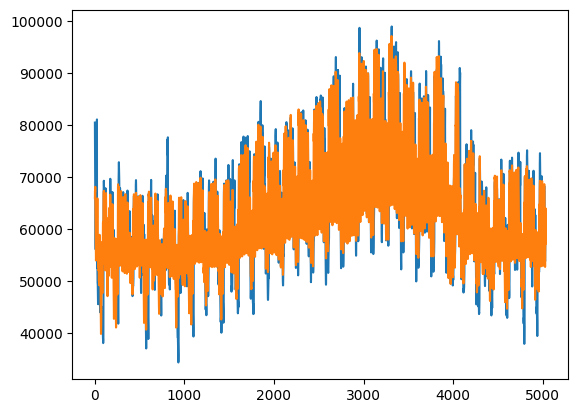

In [134]:
plt.plot(predictions_original)
plt.plot(test_y.values)

# 

real2 = test_y.values
pred2 = predictions_original
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
print(f"r2_score : {r2_score(real2, pred2):.4f}")
print(f"root_mean_squared_error : {np.sqrt(mean_squared_error(real2, pred2)):.4f}")
print(f"mean_absolute_percentage_error : {mean_absolute_percentage_error(real2, pred2):.4f}")

# SARIMAX 처리

In [77]:
scaled_train_x

array([[0.58434573, 0.30759597, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.57699251, 0.32684661, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.56773299, 0.34275265, 0.        , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.29859704, 0.9334039 , 1.        , ..., 0.        , 1.        ,
        0.        ],
       [0.30840912, 0.92522258, 1.        , ..., 0.        , 1.        ,
        0.        ],
       [0.37257208, 0.90205218, 1.        , ..., 0.        , 1.        ,
        0.        ]])

In [99]:
# ✅ Rolling Window 설정
start_index = 0
window_size = 168  # 7일치
n_periods = 24  # 하루 예측

predictions_sarimax = []
start_time = time.time()


for i in range(start_index, len(test_y), n_periods):
    try:
        step = min(n_periods, len(test_y) - i)

        # ✅ 종속변수 구성 (정규화된 값 사용)
        train_part_y = pd.DataFrame(
            scaled_train_y[max(0, len(scaled_train_y) - window_size + i):],
            columns=['power_demand'],
            index=train_y.index[max(0, len(scaled_train_y) - window_size + i):]
        )
        test_part_y = pd.DataFrame(
            scaled_test_y[:i],
            columns=['power_demand'],
            index=test_y.index[:i]
        )
        train_endog = pd.concat([train_part_y, test_part_y]).reset_index(drop=True)

        # ✅ 외생변수 구성
        train_part_x = pd.DataFrame(
            scaled_train_x[max(0, len(scaled_train_x) - window_size + i):],
            columns=train_x.columns,
            index=train_x.index[max(0, len(scaled_train_x) - window_size + i):]
        )
        test_part_x = pd.DataFrame(
            scaled_test_x[:i],
            columns=test_x.columns,
            index=test_x.index[:i]
        )
        train_exog = pd.concat([train_part_x, test_part_x]).reset_index(drop=True)

        # ✅ 모델 재학습
        print(f"🔄 SARIMAX 모델 업데이트: {i}/{len(test_y)}")
        sarimax_model = sm.tsa.SARIMAX(train_endog,
                                       exog=train_exog,
                                       order=(2, 1, 2),
                                       seasonal_order=(1, 0, 1, 24),
                                       enforce_stationarity=False,
                                       enforce_invertibility=False)
        model_fit = sarimax_model.fit(disp=False)

        # ✅ 예측 외생변수
        forecast_exog = pd.DataFrame(scaled_test_x[i:i + step])
        forecast_exog.index = pd.RangeIndex(len(forecast_exog))

        # ✅ 예측 수행
        fc = model_fit.forecast(steps=step, exog=forecast_exog)
        predictions_sarimax.extend(fc)

        # ✅ 진행 상황 출력
        if (i // n_periods + 1) % 10 == 0:
            elapsed_time = time.time() - start_time
            print(f"Processed {i + step}/{len(test_y)} steps in {elapsed_time:.2f} seconds")

    except Exception as e:
        print(f"⚠️ Step {i} 예측 실패: {e}")
        predictions_sarimax.extend([np.nan] * step)
        continue

print("✅ Rolling Window Validation 완료!")

🔄 SARIMAX 모델 업데이트: 0/5037


🔄 SARIMAX 모델 업데이트: 24/5037
🔄 SARIMAX 모델 업데이트: 48/5037
🔄 SARIMAX 모델 업데이트: 72/5037
🔄 SARIMAX 모델 업데이트: 96/5037
🔄 SARIMAX 모델 업데이트: 120/5037
🔄 SARIMAX 모델 업데이트: 144/5037
🔄 SARIMAX 모델 업데이트: 168/5037
🔄 SARIMAX 모델 업데이트: 192/5037
🔄 SARIMAX 모델 업데이트: 216/5037
Processed 240/5037 steps in 20.44 seconds
🔄 SARIMAX 모델 업데이트: 240/5037
🔄 SARIMAX 모델 업데이트: 264/5037
🔄 SARIMAX 모델 업데이트: 288/5037
🔄 SARIMAX 모델 업데이트: 312/5037
🔄 SARIMAX 모델 업데이트: 336/5037
🔄 SARIMAX 모델 업데이트: 360/5037
🔄 SARIMAX 모델 업데이트: 384/5037
🔄 SARIMAX 모델 업데이트: 408/5037
🔄 SARIMAX 모델 업데이트: 432/5037
🔄 SARIMAX 모델 업데이트: 456/5037
Processed 480/5037 steps in 59.72 seconds
🔄 SARIMAX 모델 업데이트: 480/5037
🔄 SARIMAX 모델 업데이트: 504/5037
🔄 SARIMAX 모델 업데이트: 528/5037
🔄 SARIMAX 모델 업데이트: 552/5037
🔄 SARIMAX 모델 업데이트: 576/5037
🔄 SARIMAX 모델 업데이트: 600/5037
🔄 SARIMAX 모델 업데이트: 624/5037
🔄 SARIMAX 모델 업데이트: 648/5037
🔄 SARIMAX 모델 업데이트: 672/5037
🔄 SARIMAX 모델 업데이트: 696/5037
Processed 720/5037 steps in 124.41 seconds
🔄 SARIMAX 모델 업데이트: 720/5037
🔄 SARIMAX 모델 업데이트: 744/5037
🔄 SARIMAX

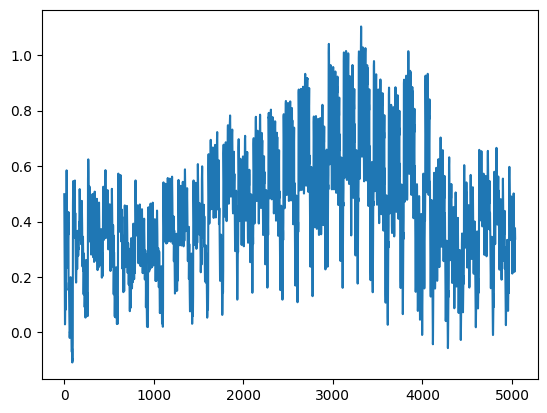

In [107]:
plt.plot(predictions_sarimax)

# 
invese_prediction = mny.inverse_transform(np.array(predictions_sarimax).reshape(-1,1))

r2_score : 0.6760
root_mean_squared_error : 6184.6915
mean_absolute_percentage_error : 0.0726


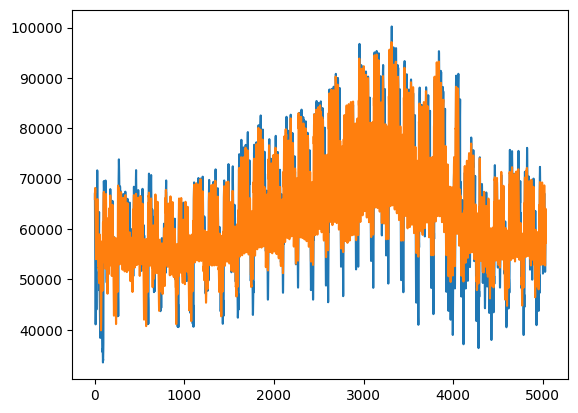

In [ ]:
plt.plot(invese_prediction.flatten())
plt.plot(test_y.values)

# 
real1 = test_y.values
pred1 = invese_prediction.flatten()
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
print(f"r2_score : {r2_score(real1, pred1):.4f}")
print(f"root_mean_squared_error : {np.sqrt(mean_squared_error(real1, pred1)):.4f}")
print(f"mean_absolute_percentage_error : {mean_absolute_percentage_error(real1, pred1):.4f}")


In [131]:
statistic = pd.DataFrame(invese_prediction, columns = ["sarimax"])
statistic["sarima"] = predictions_original

In [133]:
statistic.to_csv("statistoc_pred.csv")